# Proyek Akhir Data Mining: Preprocessing & Clustering (K-Means)
## Customer Segmentation pada Dataset *Online Retail* (UCI Machine Learning Repository)

**Nama:** Ikhram Fahrezi
**Mata Kuliah:** Data Mining
**Topik:** Preprocessing Data + Unsupervised Learning (Clustering)

---
**Dataset:** [Online Retail Dataset - UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/online+retail)
Dataset ini merupakan data transaksi nyata dari sebuah perusahaan ritel online (non-store) berbasis di UK, periode 01/12/2010 - 09/12/2011, berisi **541.909 baris transaksi**. Dataset ini dipilih karena memiliki kecacatan data yang nyata: *missing values*, data duplikat, transaksi tidak valid (pembatalan/return), serta format yang tidak konsisten — sehingga sangat relevan untuk tahap *cleaning* sebelum clustering.

**Tujuan:** Mengelompokkan pelanggan berdasarkan perilaku belanja mereka (Recency, Frequency, Monetary / RFM) menggunakan **K-Means Clustering**, agar perusahaan dapat menyusun strategi pemasaran yang lebih tepat sasaran untuk setiap segmen pelanggan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## 1. Memuat Dataset Mentah

Dataset asli (`Online_Retail_raw.csv`) dimuat tanpa modifikasi apapun untuk memastikan kita melihat kondisi data yang sebenarnya.

In [2]:
df = pd.read_csv("../data/Online_Retail_raw.csv", encoding="utf-8-sig")
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## 2. Identifikasi Kecacatan Data (Sebelum Cleaning)

Sebelum melakukan pembersihan, kita perlu memahami betul jenis dan jumlah kecacatan yang ada pada data mentah ini.

In [4]:
n_before = len(df)

missing_customer = df['CustomerID'].isnull().sum()
missing_desc = df['Description'].isnull().sum()
dup_count = df.duplicated().sum()
n_cancel = df['InvoiceNo'].astype(str).str.startswith('C').sum()
n_negqty = (df['Quantity'] < 0).sum()
n_badprice = (df['UnitPrice'] <= 0).sum()

print(f"Total baris                         : {n_before:,}")
print(f"Missing CustomerID                  : {missing_customer:,} ({missing_customer/n_before*100:.2f}%)")
print(f"Missing Description                 : {missing_desc:,}")
print(f"Baris duplikat                      : {dup_count:,}")
print(f"Transaksi pembatalan (InvoiceNo 'C') : {n_cancel:,}")
print(f"Quantity negatif (return/error)      : {n_negqty:,}")
print(f"UnitPrice <= 0 (data tidak valid)    : {n_badprice:,}")

Total baris                         : 541,909
Missing CustomerID                  : 135,080 (24.93%)
Missing Description                 : 1,454
Baris duplikat                      : 5,268
Transaksi pembatalan (InvoiceNo 'C') : 9,288
Quantity negatif (return/error)      : 10,624
UnitPrice <= 0 (data tidak valid)    : 2,517


**Catatan kecacatan data yang ditemukan:**
1. **Missing Values** — `CustomerID` kosong di ~24.9% baris (transaksi tanpa identitas pelanggan terdaftar), `Description` kosong di sejumlah baris kecil.
2. **Data Duplikat** — Ribuan baris transaksi tercatat dua kali secara identik.
3. **Format tidak konsisten** — Kolom `InvoiceDate` berupa teks (bukan datetime), `CustomerID` berupa float (seharusnya identitas integer), dan terdapat karakter BOM tersembunyi di nama kolom `InvoiceNo` saat file dibaca dengan encoding standar.
4. **Data tidak valid / outlier kategori** — Transaksi pembatalan (`InvoiceNo` diawali huruf `'C'`), `Quantity` negatif (retur barang), dan `UnitPrice` ≤ 0 (kesalahan input/adjustment).

Semua kecacatan ini akan ditangani secara bertahap pada bagian berikutnya.

## 3. Cleaning Data

### 3.1 Penanganan Missing Values
Baris tanpa `CustomerID` **dihapus**, karena tujuan analisis ini adalah menyegmentasi *pelanggan* — baris tanpa identitas pelanggan tidak bisa diikutkan dalam perhitungan RFM per customer. Untuk `Description` yang kosong, nilainya diisi (*imputasi*) dengan label `'UNKNOWN ITEM'` karena kolom ini tidak digunakan dalam perhitungan numerik clustering.

In [5]:
df = df.dropna(subset=['CustomerID'])
df['Description'] = df['Description'].fillna('UNKNOWN ITEM')
print("Ukuran setelah penanganan missing values:", df.shape)

Ukuran setelah penanganan missing values: (406829, 8)


### 3.2 Penanganan Data Duplikat

In [6]:
print("Jumlah duplikat sebelum dihapus:", df.duplicated().sum())
df = df.drop_duplicates()
print("Ukuran setelah duplikat dihapus:", df.shape)

Jumlah duplikat sebelum dihapus: 5225
Ukuran setelah duplikat dihapus: (401604, 8)


### 3.3 Standarisasi Format / Tipe Data

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceNo'] = df['InvoiceNo'].astype(str).str.strip()
df['Country'] = df['Country'].str.strip()
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              int64
Country                   str
dtype: object

### 3.4 Penanganan Data Tidak Valid (Pembatalan, Quantity & Harga Negatif)
Transaksi pembatalan dan nilai yang tidak masuk akal secara bisnis (quantity atau harga ≤ 0) dikeluarkan karena akan mendistorsi perhitungan total belanja pelanggan (Monetary).

In [8]:
is_cancel = df['InvoiceNo'].str.startswith('C')
df = df[~is_cancel]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print("Ukuran akhir data transaksi yang bersih:", df.shape)

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.to_csv("../outputs/transactions_cleaned.csv", index=False)
df.head()

Ukuran akhir data transaksi yang bersih: (392692, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**Ringkasan Cleaning:**
Dari 541.909 baris transaksi mentah, setelah seluruh proses cleaning (drop missing CustomerID, hapus duplikat, hapus transaksi tidak valid), data yang siap digunakan tersisa sebagaimana ditunjukkan output di atas — sekitar 72% dari data mentah, dengan kualitas yang valid untuk dianalisis.

## 4. Feature Engineering: RFM (Recency, Frequency, Monetary)

Dataset asli berbentuk **transaksional** (baris = satu item dalam satu invoice), sedangkan tujuan clustering adalah mengelompokkan **pelanggan**. Maka, data ditransformasi ke level pelanggan menggunakan model **RFM**:

- **Recency** — jumlah hari sejak transaksi terakhir pelanggan (semakin kecil = semakin baru aktif belanja)
- **Frequency** — jumlah invoice (transaksi) unik yang pernah dilakukan pelanggan
- **Monetary** — total nilai uang yang pernah dibelanjakan pelanggan

In [9]:
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("Jumlah pelanggan unik untuk clustering:", rfm.shape[0])
rfm.describe()

Jumlah pelanggan unik untuk clustering: 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


### 4.1 Penanganan Outlier
Distribusi `Frequency` dan `Monetary` sangat *skewed* (ada pelanggan wholesaler dengan nilai belanja sangat ekstrem dibanding mayoritas). Outlier ini dapat mendominasi proses clustering jika tidak ditangani, sehingga dilakukan **capping** menggunakan metode IQR (nilai di atas batas atas dipotong ke batas atas, bukan dihapus, agar pelanggan tersebut tetap terhitung tapi tidak mendominasi jarak euclidean).

In [10]:
def cap_iqr(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + k * iqr
    return series.clip(upper=upper)

rfm['Frequency'] = cap_iqr(rfm['Frequency'])
rfm['Monetary'] = cap_iqr(rfm['Monetary'])
rfm.to_csv("../outputs/rfm_table.csv", index=False)
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,3.772015,1301.271330
std,1721.808492,100.014169,3.866504,1508.304019
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,17.000000,5722.942500


## 5. Scaling / Standarisasi

K-Means menggunakan jarak Euclidean, sehingga fitur dengan skala besar (misalnya `Monetary` dalam ribuan poundsterling) akan mendominasi fitur dengan skala kecil (`Recency` dalam satuan hari) jika tidak distandarisasi. Maka seluruh fitur RFM distandarisasi dengan **StandardScaler** (mean=0, std=1).

In [11]:
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 2.33457414, -0.71701312,  2.93188962],
       [-0.90534032,  0.83495508,  1.99500597],
       [-0.17535959,  0.05897098,  0.32886331],
       [-0.73534481, -0.71701312,  0.30254595],
       [ 2.17457836, -0.71701312, -0.64110602]])

## 6. Menentukan Jumlah Cluster Optimal (Elbow Method & Silhouette Score)

Dua metode dipakai untuk menentukan jumlah cluster (k) terbaik:
- **Elbow Method** — melihat titik di mana penurunan *inertia* (Within-Cluster Sum of Squares) mulai melandai
- **Silhouette Score** — mengukur seberapa baik tiap titik data cocok dengan clusternya sendiri dibanding cluster lain (semakin mendekati 1 semakin baik)

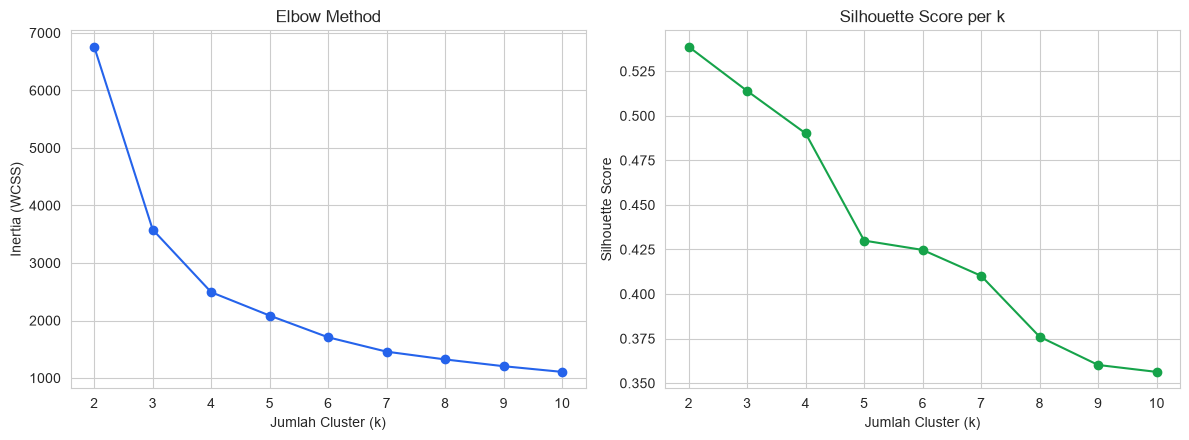

k=2 | inertia=6760.3 | silhouette=0.5387
k=3 | inertia=3580.0 | silhouette=0.5139
k=4 | inertia=2492.2 | silhouette=0.4901
k=5 | inertia=2085.2 | silhouette=0.4300
k=6 | inertia=1707.8 | silhouette=0.4248
k=7 | inertia=1458.1 | silhouette=0.4102
k=8 | inertia=1322.9 | silhouette=0.3760
k=9 | inertia=1205.2 | silhouette=0.3602
k=10 | inertia=1106.3 | silhouette=0.3563


In [12]:
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(K_range), inertias, marker='o', color="#2563eb")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(K_range), sil_scores, marker='o', color="#16a34a")
axes[1].set_title("Silhouette Score per k")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k} | inertia={i:.1f} | silhouette={s:.4f}")

**Interpretasi:**
Silhouette score tertinggi secara statistik murni berada di **k=2**, namun itu hanya membedakan pelanggan "aktif" vs "tidak aktif" — kurang *actionable* untuk strategi bisnis. Grafik Elbow menunjukkan penurunan inertia mulai melandai signifikan pada **k=4**, dan k=4 juga merupakan jumlah segmen standar dalam analisis RFM (*Champions, Loyal Customers, At Risk, Hibernating/Lost*) dengan silhouette score yang masih tergolong baik (≈0.49). Oleh karena itu, **k=4** dipilih sebagai jumlah cluster final — mempertimbangkan trade-off antara skor statistik dan interpretasi bisnis.

## 7. Implementasi K-Means (Model Final)

In [13]:
best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, rfm['Cluster'])
print(f"Silhouette Score model final (k={best_k}): {final_sil:.4f}")

rfm.to_csv("../outputs/rfm_clustered.csv", index=False)
rfm.head()

Silhouette Score model final (k=4): 0.4901


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,5722.9425,2
1,12347,2,7,4310.0000,3
2,12348,75,4,1797.2400,3
3,12349,19,1,1757.5500,1
4,12350,310,1,334.4000,2


## 8. Visualisasi Hasil Clustering

### 8.1 Visualisasi 2D (PCA)
Karena RFM memiliki 3 dimensi, digunakan **PCA (Principal Component Analysis)** untuk memproyeksikan data ke 2 dimensi agar dapat divisualisasikan dalam scatter plot, sambil tetap mempertahankan sebagian besar variansi data.

Variansi yang dijelaskan oleh 2 komponen PCA: 94.3%


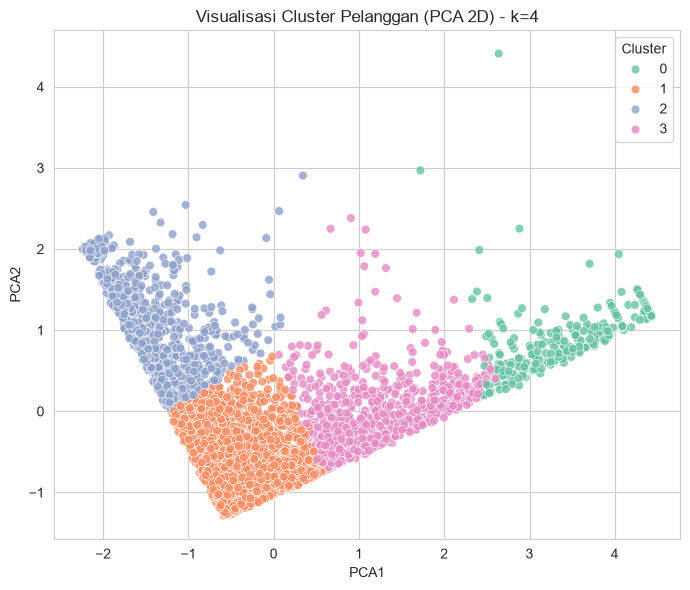

In [14]:
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_scaled)
rfm['PCA1'] = pca_2d[:, 0]
rfm['PCA2'] = pca_2d[:, 1]

print(f"Variansi yang dijelaskan oleh 2 komponen PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(7, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=40, alpha=0.8)
plt.title(f"Visualisasi Cluster Pelanggan (PCA 2D) - k={best_k}")
plt.tight_layout()
plt.show()

### 8.2 Visualisasi 3D (Recency, Frequency, Monetary Asli)

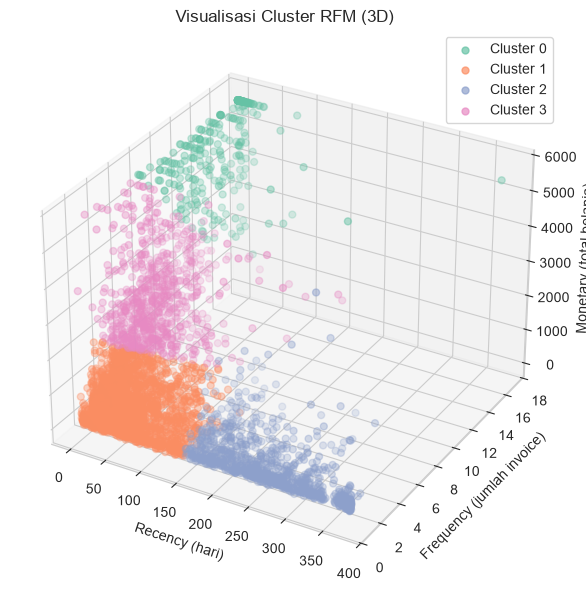

In [15]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colors = sns.color_palette('Set2', best_k)
for c in sorted(rfm['Cluster'].unique()):
    sub = rfm[rfm['Cluster'] == c]
    ax.scatter(sub['Recency'], sub['Frequency'], sub['Monetary'],
               label=f'Cluster {c}', color=colors[c], alpha=0.7, s=25)
ax.set_xlabel('Recency (hari)')
ax.set_ylabel('Frequency (jumlah invoice)')
ax.set_zlabel('Monetary (total belanja)')
ax.set_title('Visualisasi Cluster RFM (3D)')
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Distribusi Tiap Fitur per Cluster (Boxplot)

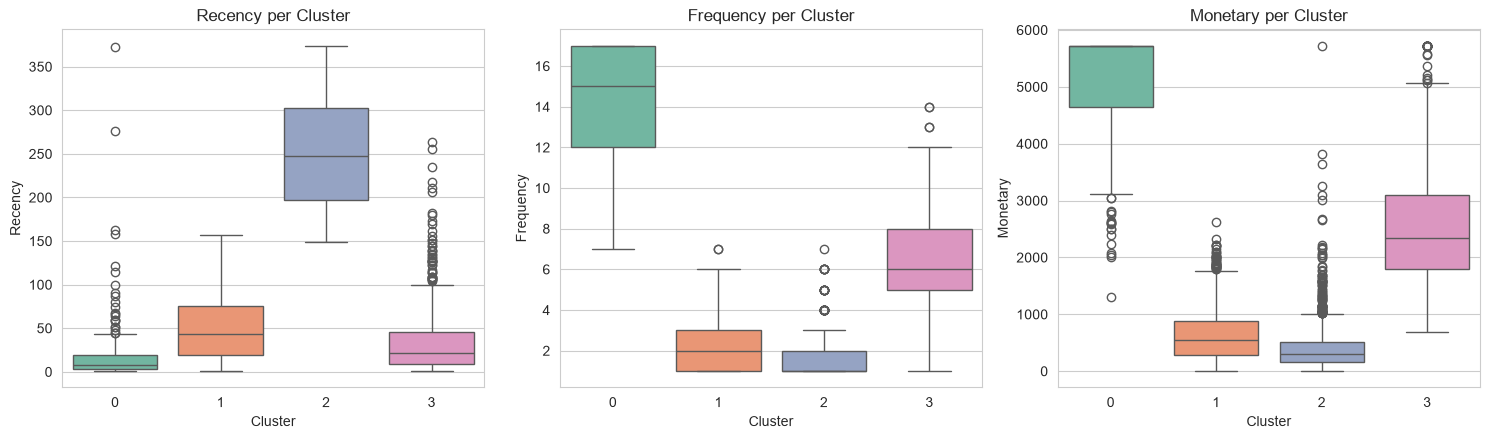

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(data=rfm, x='Cluster', y=col, hue='Cluster', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{col} per Cluster')
plt.tight_layout()
plt.show()

## 9. Profil & Interpretasi Bisnis Tiap Cluster

In [17]:
profile = rfm.groupby('Cluster').agg(
    Jumlah_Customer=('CustomerID', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean')
).round(1)
profile['Persentase'] = (profile['Jumlah_Customer'] / profile['Jumlah_Customer'].sum() * 100).round(1)
profile.to_csv("../outputs/cluster_profile.csv")
profile

,Jumlah_Customer,Recency_Mean,Frequency_Mean,Monetary_Mean,Persentase
Cluster,,,,,
0,340,16.5,14.3,5113.3,7.8
1,2168,51.6,2.2,634.4,50.0
2,1013,252.9,1.5,428.5,23.4
3,817,33.8,6.3,2566.7,18.8


**Interpretasi tiap cluster (berdasarkan hasil aktual di atas):**

| Cluster | Karakteristik | Label Segmen |
|---|---|---|
| **0** | Recency rendah (baru belanja), Frequency tinggi, Monetary tertinggi | 🏆 **Champions** — pelanggan paling bernilai, perlu dipertahankan & diberi program loyalitas eksklusif |
| **3** | Recency cukup rendah, Frequency & Monetary menengah-tinggi | 💎 **Loyal Customers** — pelanggan setia, potensial untuk upsell/cross-sell |
| **1** | Recency menengah, Frequency & Monetary rendah | 🙂 **Regular/Potential Customers** — kelompok terbesar, butuh strategi re-engagement agar naik kelas |
| **2** | Recency tertinggi (lama tidak belanja), Frequency & Monetary terendah | 😴 **Hibernating/At Risk Customers** — perlu kampanye win-back atau promo khusus agar tidak churn |

Label di atas disusun berdasarkan urutan nilai rata-rata Recency/Frequency/Monetary pada tabel profil di atas — silakan cocokkan dengan nomor cluster aktual pada output untuk memastikan urutan label sesuai data terbaru.

## 10. Kesimpulan

1. Dataset transaksi mentah Online Retail memiliki kecacatan signifikan (missing values ~25%, duplikat, data tidak valid) yang berhasil ditangani melalui tahap cleaning sistematis.
2. Data transaksional ditransformasi menjadi data level-pelanggan menggunakan pendekatan RFM agar sesuai untuk clustering.
3. K-Means dengan k=4 (dipilih berdasarkan kombinasi Elbow Method, Silhouette Score, dan kebutuhan interpretasi bisnis) menghasilkan segmentasi pelanggan yang jelas dan dapat ditindaklanjuti secara bisnis (Champions, Loyal, Regular/Potential, Hibernating).
4. Hasil clustering ini dapat digunakan perusahaan untuk menyusun strategi pemasaran yang berbeda untuk setiap segmen, misalnya program loyalitas untuk Champions dan kampanye win-back untuk segmen Hibernating.